### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from wordcloud import WordCloud
from textblob import TextBlob

### Loading the Data

In [14]:
data = pd.read_csv("banking_feedback.csv")
data.head()

,Sentences
0,Transaction search filters don’t work properly.
1,I loved the cashback I received on my utility ...
2,Loan disbursal was quick and required minimal ...
3,The auto-pay feature didn’t work and led to pe...
4,Refund from a failed transaction took more tha...


### Defining Sentiment Analysis

In [15]:
def get_sentiment(text):
    meaning = TextBlob(text)
    if meaning.sentiment.polarity > 0:
        return "Positive"
    elif meaning.sentiment.polarity < 0:
        return "Negative"
    else:
        return "Neutral"

### Applying Sentiment Analysis

In [16]:
data["Sentiment"]= data["Sentences"].apply(get_sentiment)

In [17]:
data

,Sentences,Sentiment
0,Transaction search filters don’t work properly.,Neutral
1,I loved the cashback I received on my utility ...,Positive
2,Loan disbursal was quick and required minimal ...,Positive
3,The auto-pay feature didn’t work and led to pe...,Neutral
4,Refund from a failed transaction took more tha...,Neutral
...,...,...
105,Dispute resolution took much longer than promi...,Positive
106,I appreciate the secure two-factor authenticat...,Positive
107,The bank sends monthly statements by email.,Neutral
108,There were hidden charges in my loan processin...,Negative


### Understanding Sentiment Percentage using Pie Chart

In [21]:
x = data["Sentiment"].value_counts()
x

Sentiment
Neutral     48
Positive    39
Negative    23
Name: count, dtype: int64

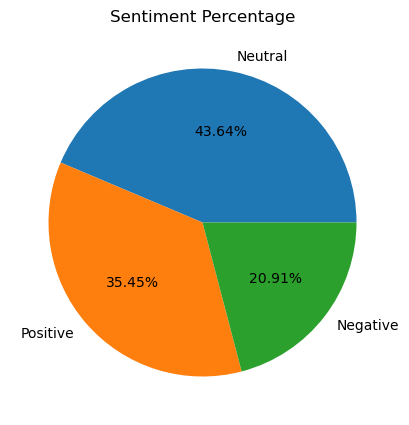

In [22]:
plt.figure(figsize=(10,5))
plt.pie(x, labels=x.index, autopct="%.2f%%")
plt.title("Sentiment Percentage")


In [33]:
# Downloading the new text file after adding sentiment column

In [31]:
data.to_excel("C247_banking_feedback_sentiment_analysis.xlsx")

### Filtering all Negative Reviews

In [25]:
negatives = data[data["Sentiment"] == "Negative"]
negatives.head()

,Sentences,Sentiment
10,The credit score section shows outdated inform...,Negative
11,The bank took too long to issue a closure cert...,Negative
22,Customer service representatives were rude and...,Negative
24,The foreign transaction process was hassle-fre...,Negative
30,My loan balance wasn’t updated after partial p...,Negative


### Merging all Negative Reviews into a single string

In [26]:
all_negatives_merged = " ".join(negatives["Sentences"])
all_negatives_merged

'The credit score section shows outdated information. The bank took too long to issue a closure certificate. Customer service representatives were rude and unhelpful. The foreign transaction process was hassle-free and transparent. My loan balance wasn’t updated after partial prepayment. EMI payment reminders are timely and help me avoid late fees. The EMI auto-debit failed despite sufficient balance. The loan approval process was unnecessarily complicated. Customer service took too long to answer my call. I faced delays in loan disbursal due to missing communication. The UPI transaction failed but the amount was still debited. Loan officer arrived late and missed our appointment. I was charged a late fee even though I paid on time. The mobile app login often fails due to server issues. I didn’t receive any acknowledgment after raising a complaint. My card replacement request was fulfilled earlier than expected. Customer service was extremely polite and helped me understand my credit s

### Creating Word Cloud for the negative reviews

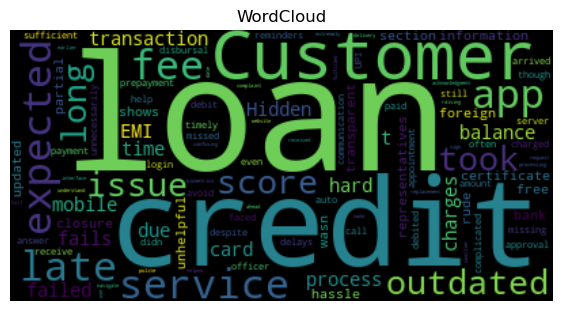

In [50]:
y = WordCloud(width=400,height=200,background_color="black").generate(all_negatives_merged)

# Plot the word cloud
plt.figure(figsize=(7,8))
plt.imshow(y, interpolation = "bilinear")  # interpolation is used for vertical and horizontal outcomes at the same time in wordcloud
plt.title("WordCloud")
plt.axis("off")
plt.show()